#Importing the libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import accuracy_score

#Data Collection and Processing

## loading the csv data to a Pandas dataFrame

In [34]:
gold_data=pd.read_csv('/content/gld_price_data.csv')

# print first 5 rows in dataframe


In [35]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


# print last 5 rows in dataframe

In [36]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


# no. of rows and coloumn

In [37]:
gold_data.shape

(2290, 6)

# getting some basic information about the data

In [38]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


#  checking the number of missing values

In [39]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


# getting the statistical measures of the data

In [40]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


# constructing a heatmap to understand the correlation

<Axes: >

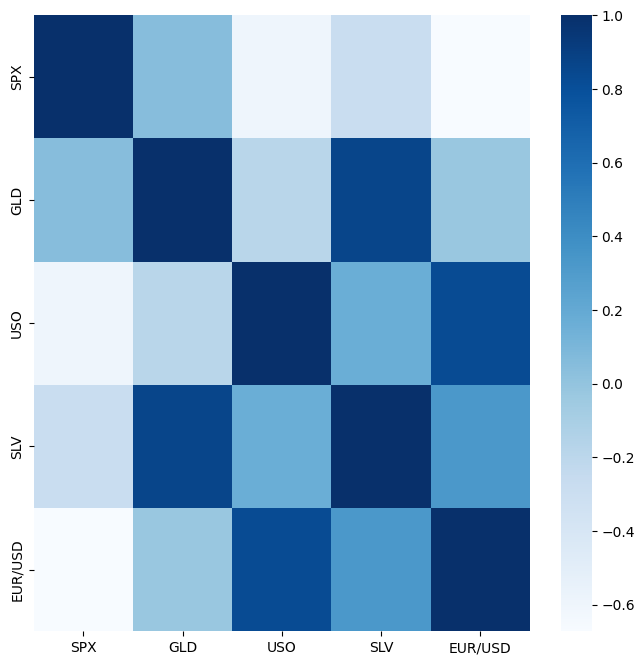

In [41]:
plt.figure(figsize = (8,8))
sns.heatmap(correlation,
cbar=True,
annot_kws={'size':8}, cmap='Blues')


# correlation values of GLD

In [42]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


# Checking the distribution of the GLD Price

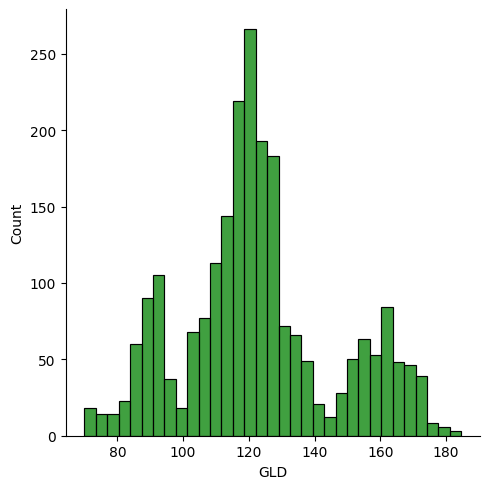

In [43]:
sns.displot(gold_data['GLD'],color='green')

In [44]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [45]:
print(X)


              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [46]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


#Splitting into Training data and Test Data

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2,
random_state=2)

#Model Training: Random Forest Regressor

In [48]:
regressor = RandomForestRegressor(n_estimators=100)

# training the model

In [49]:
regressor.fit(X_train,Y_train)

RandomForestRegressor()

#Model Evaluation:
## prediction on Test Data

In [50]:
test_data_prediction = regressor.predict(X_test)
print(test_data_prediction)

[168.49429977  81.88700021 115.67599988 127.43930074 120.54930119
 154.63059799 150.39669842 125.9551003  117.55629874 126.01190102
 116.56350072 171.76370115 141.64279897 167.94769865 115.06470018
 117.62380059 138.80280348 170.02570053 160.07490288 158.97339848
 155.1272001  125.40400011 175.81260006 156.81310336 125.20720067
  94.04119989  77.61960012 120.84250001 119.0908994  167.44849957
  88.17150015 125.20430007  91.15020097 117.67210013 121.04439926
 136.41040043 115.62280116 115.74590085 146.97409986 107.2095009
 104.11230237  87.20769811 126.51070022 117.58660005 154.99679869
 119.59850024 108.30700024 108.00439818  93.32680061 127.15659773
  74.73190035 113.71439926 121.16669986 111.31679921 118.86619859
 120.82349911 159.23770041 168.6730008  146.80129701  85.93269854
  94.28340034  86.85279862  90.39029991 118.96230041 126.47430053
 127.66210024 167.91019924 122.23109923 117.54789871  98.61710014
 168.32580056 143.31529791 131.89170282 121.0750023  121.53659927
 119.727700

# R squared error

In [51]:
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error: ", error_score)

R squared error:  0.9895050664282659


#Compare the Actual Values and Predicted Values in a Plot

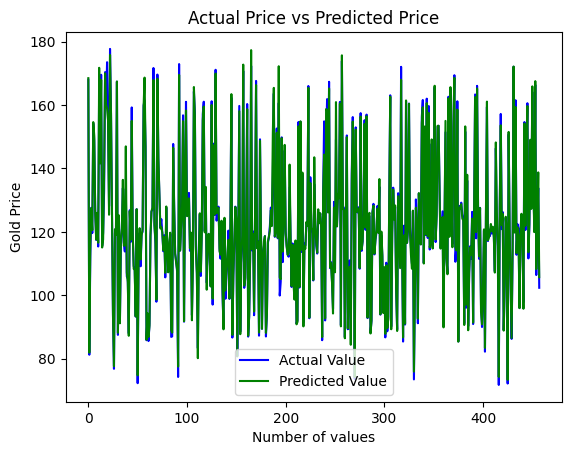

In [52]:
Y_test = list(Y_test)
plt.plot(Y_test, color='blue', label ='Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('Gold Price')
plt.legend()
plt.show()